In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("All libraries loaded.")

All libraries loaded.


In [2]:
from src.data.loader import BookCrossingLoader
from src.data.preprocessor import BookCrossingPreprocessor

loader = BookCrossingLoader("../data/raw")
raw = loader.load_all(verbose=False)

prep = BookCrossingPreprocessor()
clean = prep.fit_transform(raw)

users   = clean.users
books   = clean.books
ratings = clean.ratings

print(f"Users:   {len(users):,}")
print(f"Books:   {len(books):,}")
print(f"Ratings: {len(ratings):,}")

Users:   278,859
Books:   271,378
Ratings: 1,149,753


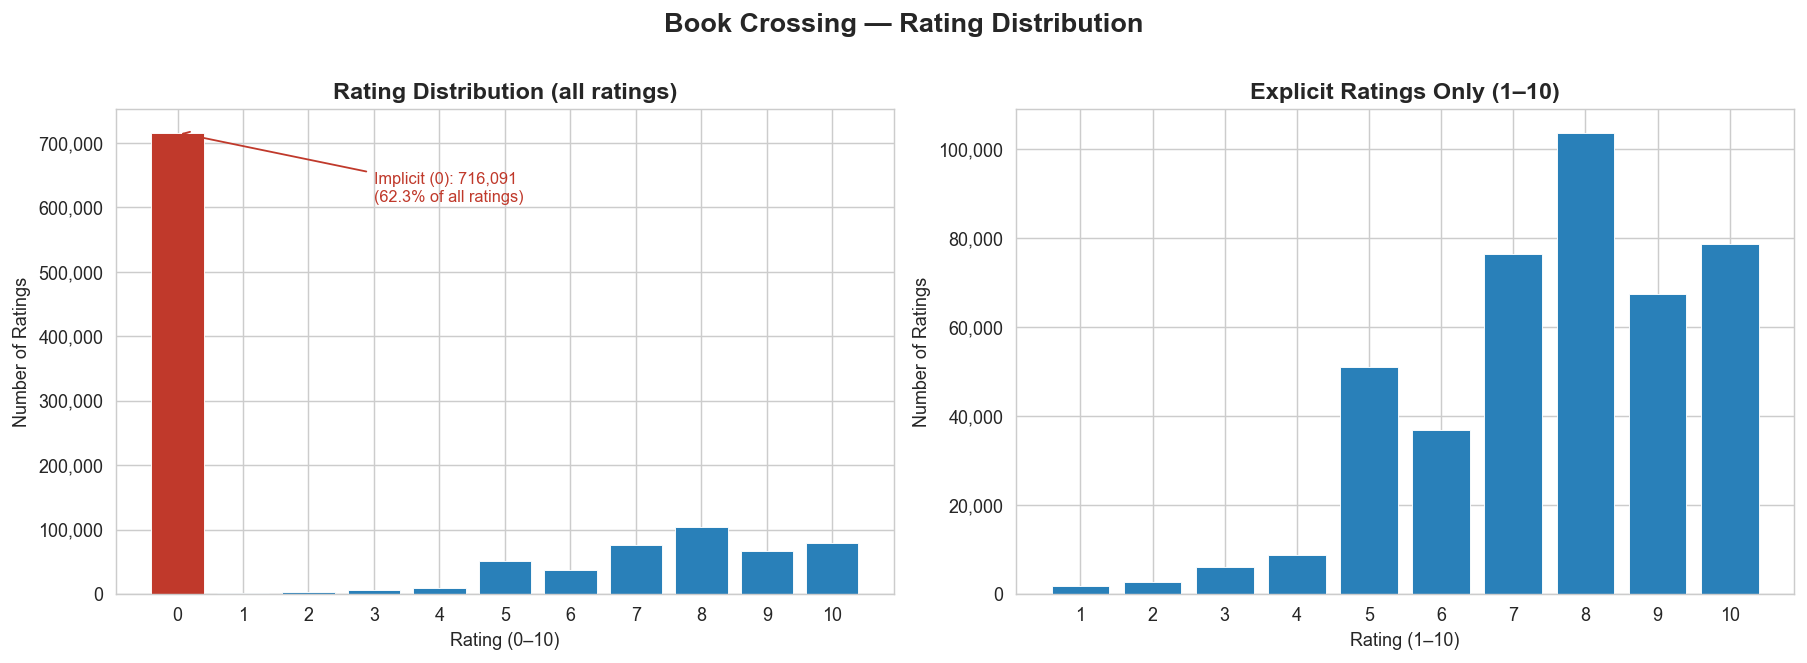

Implicit ratings (0): 716,091 (62.3%)
Explicit ratings (1-10): 433,662 (37.7%)


In [3]:
rating_counts = ratings['rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all ratings including 0
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#c0392b' if r == 0 else '#2980b9' for r in rating_counts.index],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Rating Distribution (all ratings)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (0–10)')
axes[0].set_ylabel('Number of Ratings')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_xticks(range(0, 11))

# Right: explicit ratings only (1–10)
explicit = rating_counts[rating_counts.index > 0]
axes[1].bar(explicit.index, explicit.values, color='#2980b9',
            edgecolor='white', linewidth=0.5)
axes[1].set_title('Explicit Ratings Only (1–10)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating (1–10)')
axes[1].set_ylabel('Number of Ratings')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_xticks(range(1, 11))

# Annotation: implicit rating count
implicit_count = rating_counts[0]
axes[0].annotate(f'Implicit (0): {implicit_count:,}\n({implicit_count/len(ratings)*100:.1f}% of all ratings)',
                 xy=(0, implicit_count), xytext=(3, implicit_count * 0.85),
                 fontsize=9, color='#c0392b',
                 arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1))

plt.suptitle('Book Crossing — Rating Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/rating_distribution.png', bbox_inches='tight')
plt.show()
print(f"Implicit ratings (0): {implicit_count:,} ({implicit_count/len(ratings)*100:.1f}%)")
print(f"Explicit ratings (1-10): {len(ratings) - implicit_count:,} ({(len(ratings)-implicit_count)/len(ratings)*100:.1f}%)")

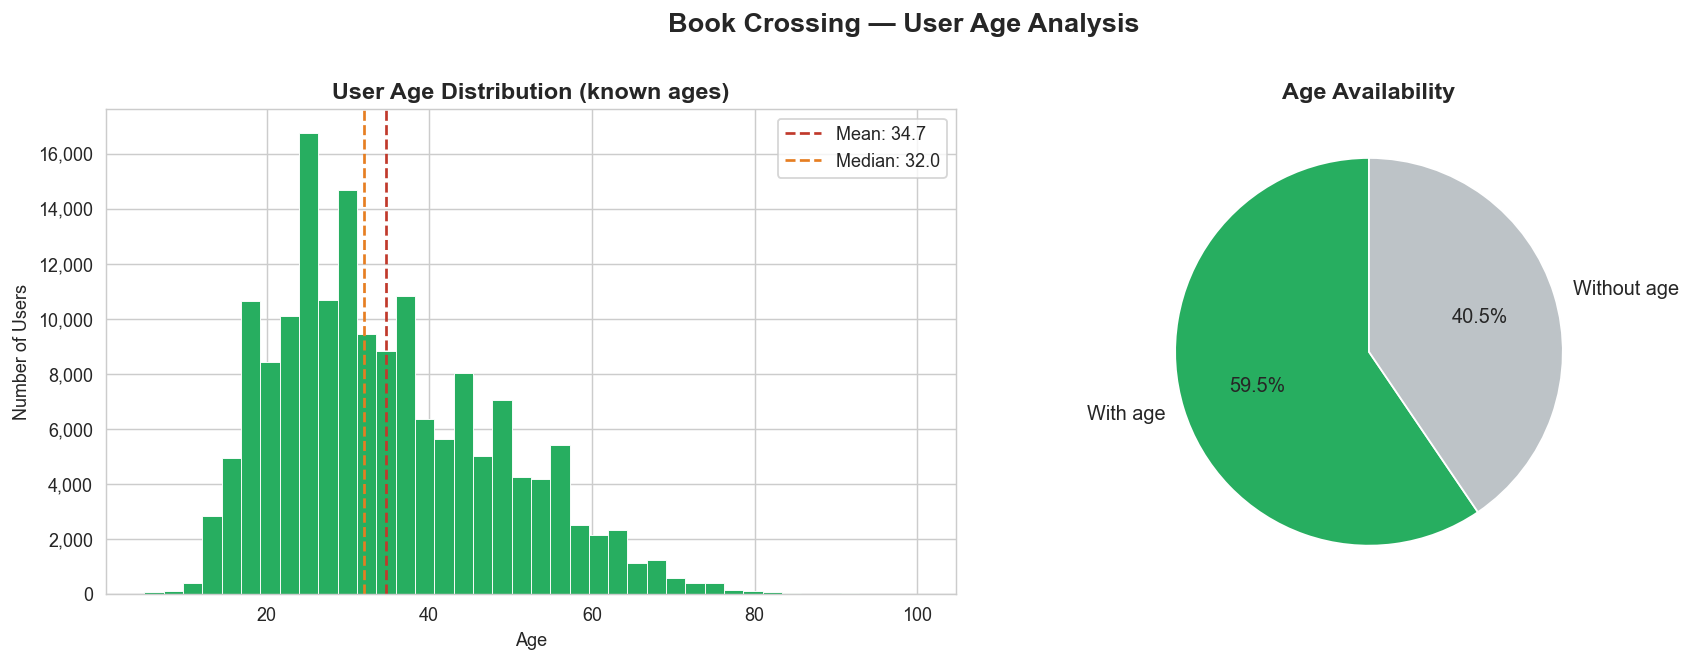

Users with known age:    165,917 (59.5%)
Users without age:       112,942 (40.5%)
Age range: 5 – 100
Mean age: 34.7  |  Median age: 32.0


In [4]:
known_ages = users[users['age'].notna()]['age']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
axes[0].hist(known_ages, bins=40, color='#27ae60', edgecolor='white', linewidth=0.5)
axes[0].axvline(known_ages.mean(), color='#c0392b', linestyle='--', linewidth=1.5,
                label=f'Mean: {known_ages.mean():.1f}')
axes[0].axvline(known_ages.median(), color='#e67e22', linestyle='--', linewidth=1.5,
                label=f'Median: {known_ages.median():.1f}')
axes[0].set_title('User Age Distribution (known ages)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()

# Right: pie chart — with vs without age
labels = ['With age', 'Without age']
sizes  = [clean.n_users_with_age, clean.n_users_without_age]
colors = ['#27ae60', '#bdc3c7']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Age Availability', fontsize=13, fontweight='bold')

plt.suptitle('Book Crossing — User Age Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/age_distribution.png', bbox_inches='tight')
plt.show()
print(f"Users with known age:    {clean.n_users_with_age:,} ({clean.n_users_with_age/clean.n_users*100:.1f}%)")
print(f"Users without age:       {clean.n_users_without_age:,} ({clean.n_users_without_age/clean.n_users*100:.1f}%)")
print(f"Age range: {int(known_ages.min())} – {int(known_ages.max())}")
print(f"Mean age: {known_ages.mean():.1f}  |  Median age: {known_ages.median():.1f}")

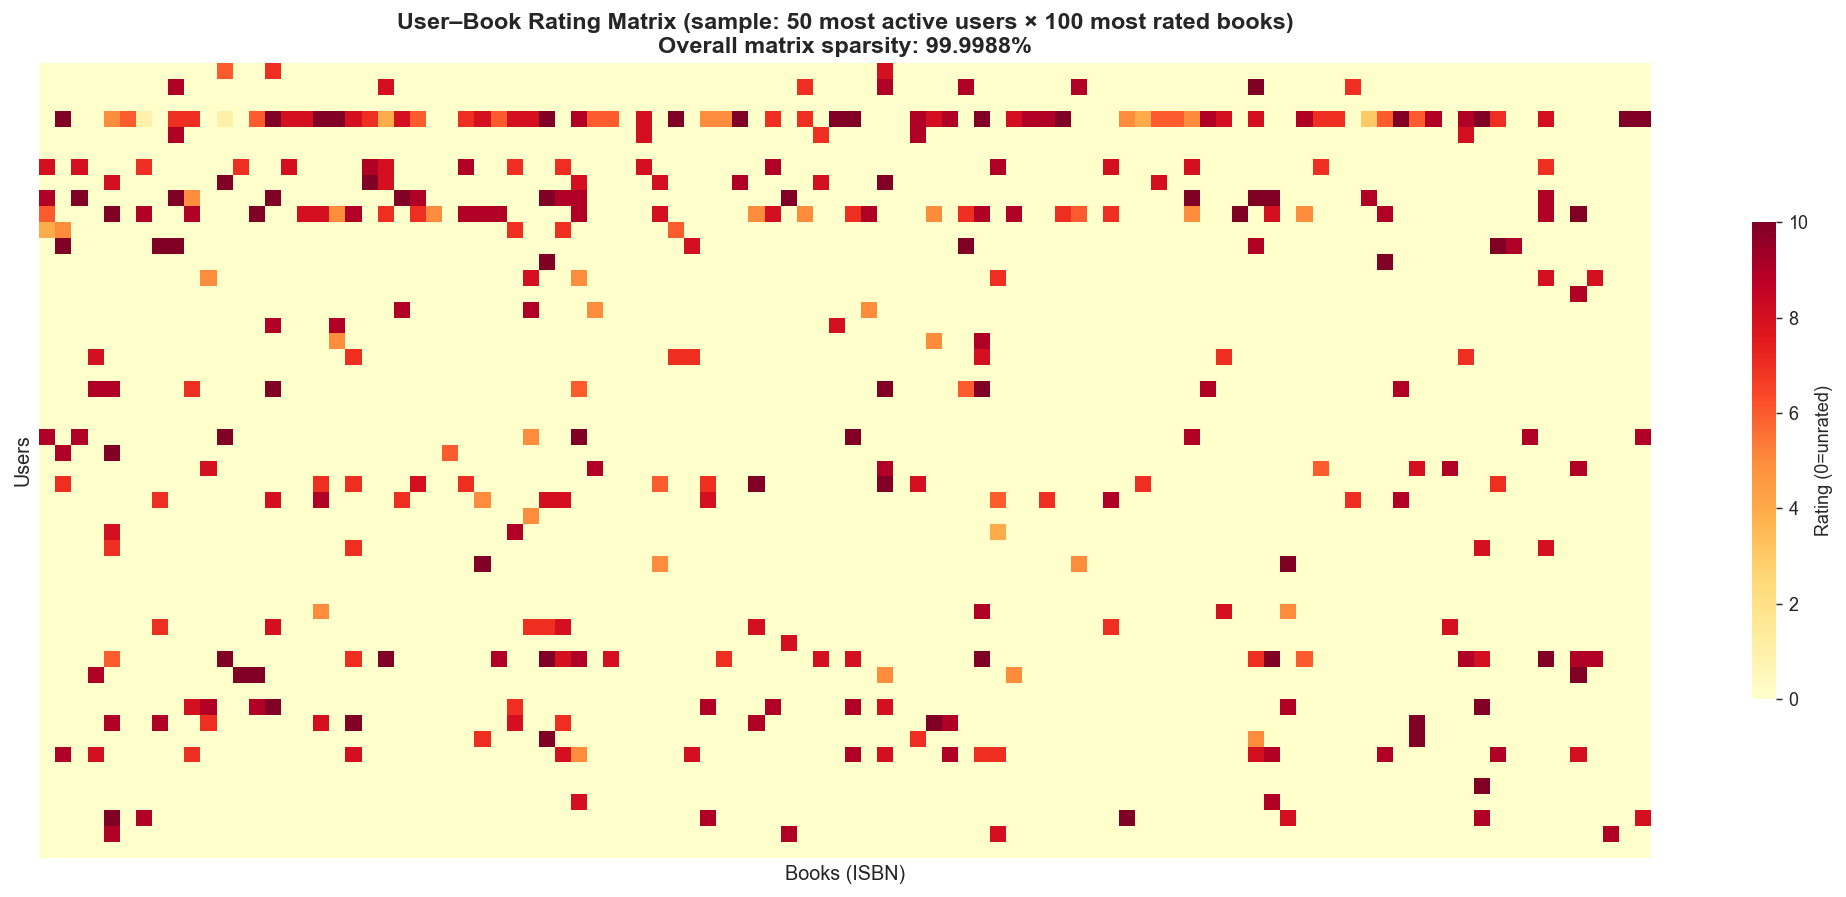

Overall matrix sparsity: 99.998788%
(Most cells are 0 — users have only rated a tiny fraction of all books)


In [5]:
# Sample 50 users and 100 books for visualization
sample_users = ratings['user_id'].value_counts().head(50).index.tolist()
sample_ratings = ratings[ratings['user_id'].isin(sample_users)]
top_books = sample_ratings['isbn'].value_counts().head(100).index.tolist()
sample_ratings = sample_ratings[sample_ratings['isbn'].isin(top_books)]

matrix = sample_ratings.pivot_table(
    index='user_id', columns='isbn',
    values='rating', fill_value=0
).reindex(columns=top_books, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(matrix, cmap='YlOrRd', linewidths=0, linecolor='none',
            cbar_kws={'label': 'Rating (0=unrated)', 'shrink': 0.6},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title(
    f'User–Book Rating Matrix (sample: 50 most active users × 100 most rated books)\n'
    f'Overall matrix sparsity: {clean.sparsity:.4%}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Books (ISBN)', fontsize=11)
ax.set_ylabel('Users', fontsize=11)
plt.tight_layout()
plt.savefig('../assets/sparsity_heatmap.png', bbox_inches='tight')
plt.show()
print(f"Overall matrix sparsity: {clean.sparsity:.6%}")
print("(Most cells are 0 — users have only rated a tiny fraction of all books)")

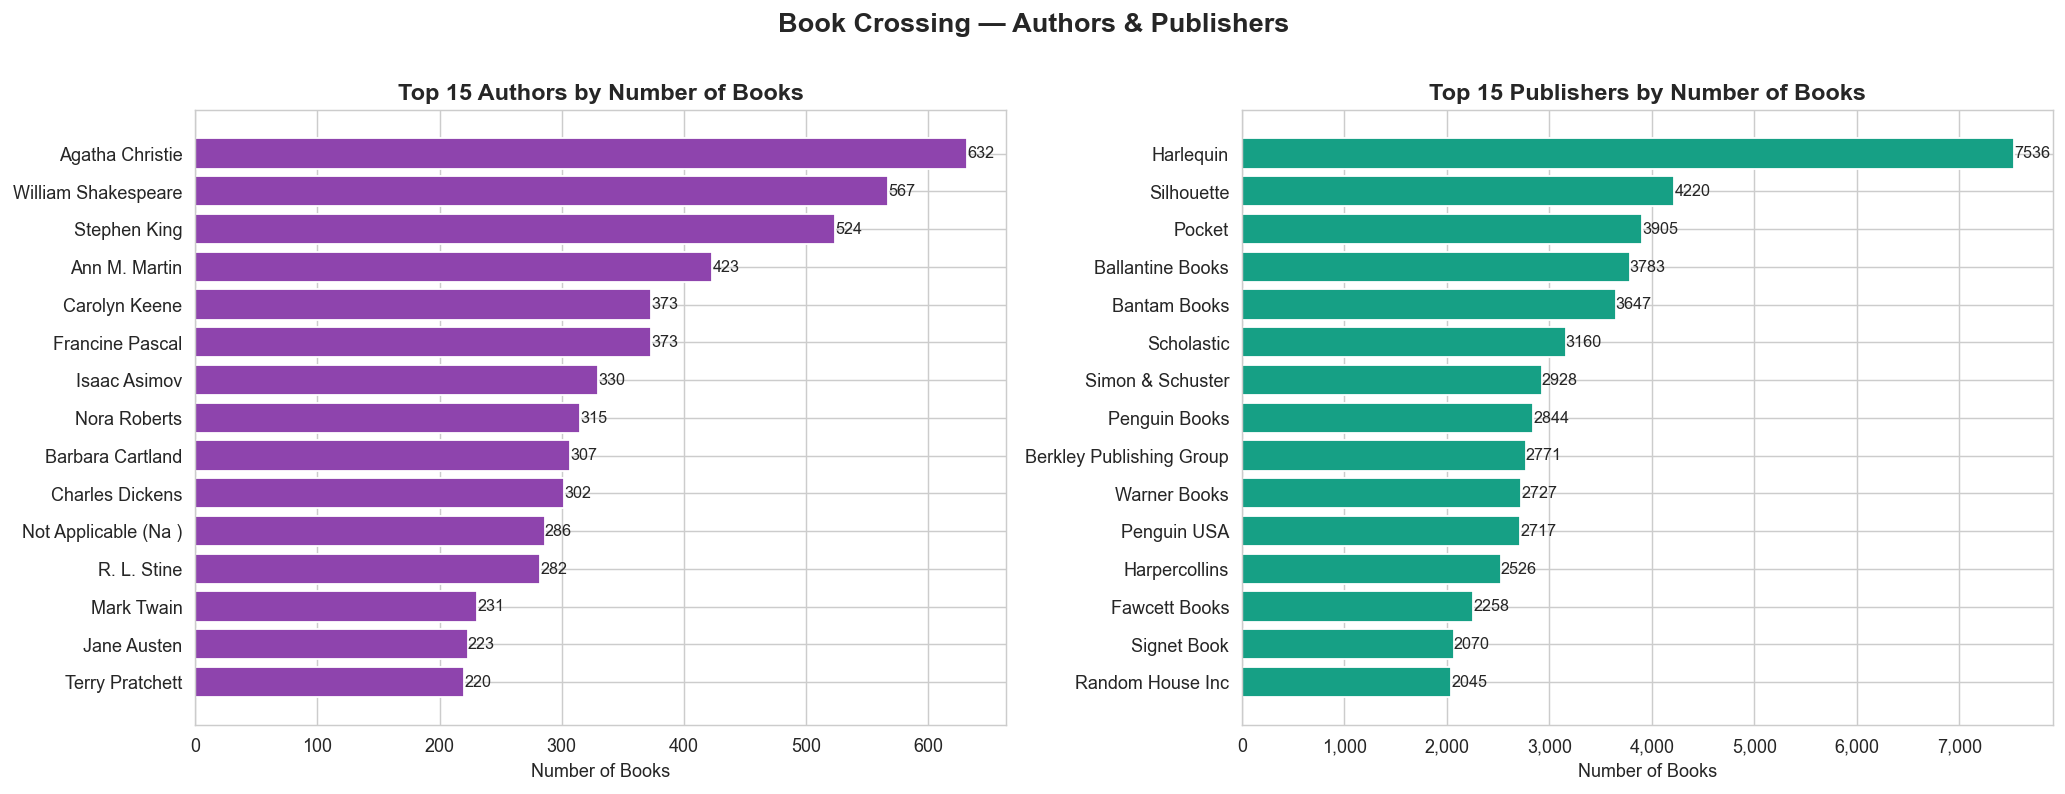

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 authors by number of books
top_authors = books['author'].value_counts().head(15)
axes[0].barh(top_authors.index[::-1], top_authors.values[::-1], color='#8e44ad')
axes[0].set_title('Top 15 Authors by Number of Books', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Books')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(top_authors.values[::-1]):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)

# Top 15 publishers
top_publishers = books['publisher'].value_counts().head(15)
axes[1].barh(top_publishers.index[::-1], top_publishers.values[::-1], color='#16a085')
axes[1].set_title('Top 15 Publishers by Number of Books', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Books')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(top_publishers.values[::-1]):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.suptitle('Book Crossing — Authors & Publishers', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/top_authors_publishers.png', bbox_inches='tight')
plt.show()

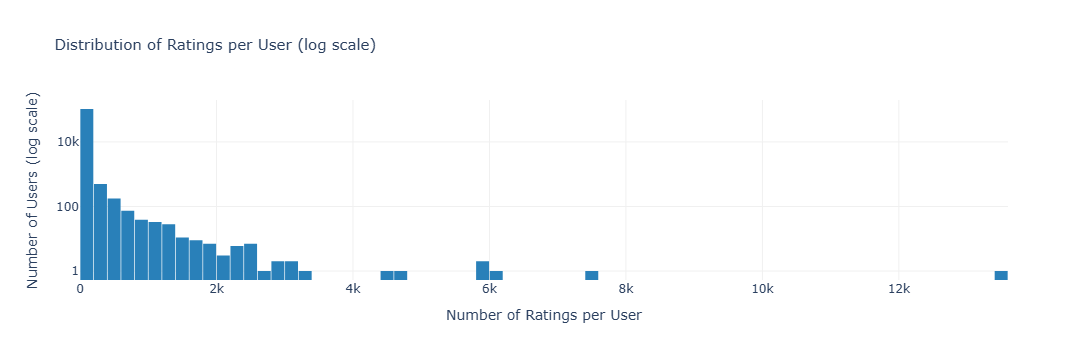

Mean ratings per user:   10.9
Median ratings per user: 1.0
Max ratings by one user: 13,599
Users with only 1 rating: 59,166


In [7]:
ratings_per_user = ratings.groupby('user_id').size().reset_index(name='n_ratings')

fig = px.histogram(
    ratings_per_user,
    x='n_ratings',
    nbins=80,
    log_y=True,
    title='Distribution of Ratings per User (log scale)',
    labels={'n_ratings': 'Number of Ratings', 'count': 'Number of Users'},
    color_discrete_sequence=['#2980b9']
)
fig.update_layout(
    title_font_size=15,
    xaxis_title='Number of Ratings per User',
    yaxis_title='Number of Users (log scale)',
    bargap=0.05,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12)
)
fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0')
fig.show()

print(f"Mean ratings per user:   {ratings_per_user['n_ratings'].mean():.1f}")
print(f"Median ratings per user: {ratings_per_user['n_ratings'].median():.1f}")
print(f"Max ratings by one user: {ratings_per_user['n_ratings'].max():,}")
print(f"Users with only 1 rating: {(ratings_per_user['n_ratings'] == 1).sum():,}")

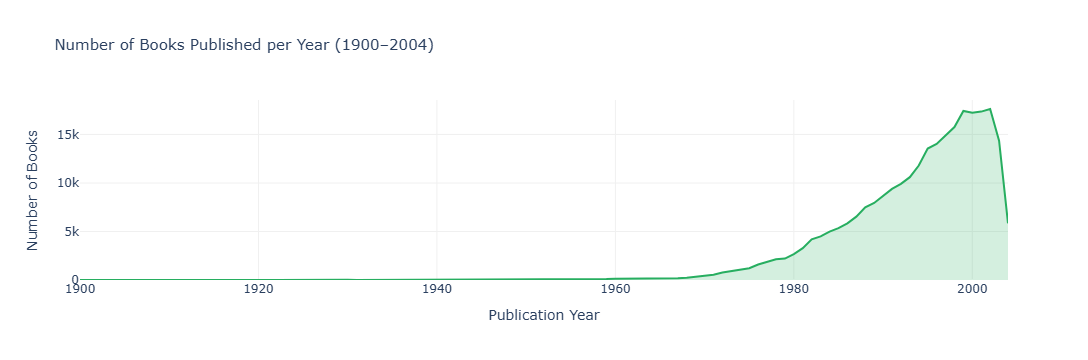

Peak publication year: 2002 (17,628 books)


In [8]:
year_counts = books[books['year'].notna()]['year'].astype(int).value_counts().sort_index()
year_counts = year_counts[(year_counts.index >= 1900) & (year_counts.index <= 2004)]

fig = px.area(
    x=year_counts.index,
    y=year_counts.values,
    title='Number of Books Published per Year (1900–2004)',
    labels={'x': 'Publication Year', 'y': 'Number of Books'},
    color_discrete_sequence=['#27ae60']
)
fig.update_layout(
    title_font_size=15,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12)
)
fig.update_traces(fillcolor='rgba(39, 174, 96, 0.2)', line_color='#27ae60')
fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0')
fig.show()

peak_year = year_counts.idxmax()
print(f"Peak publication year: {peak_year} ({year_counts[peak_year]:,} books)")

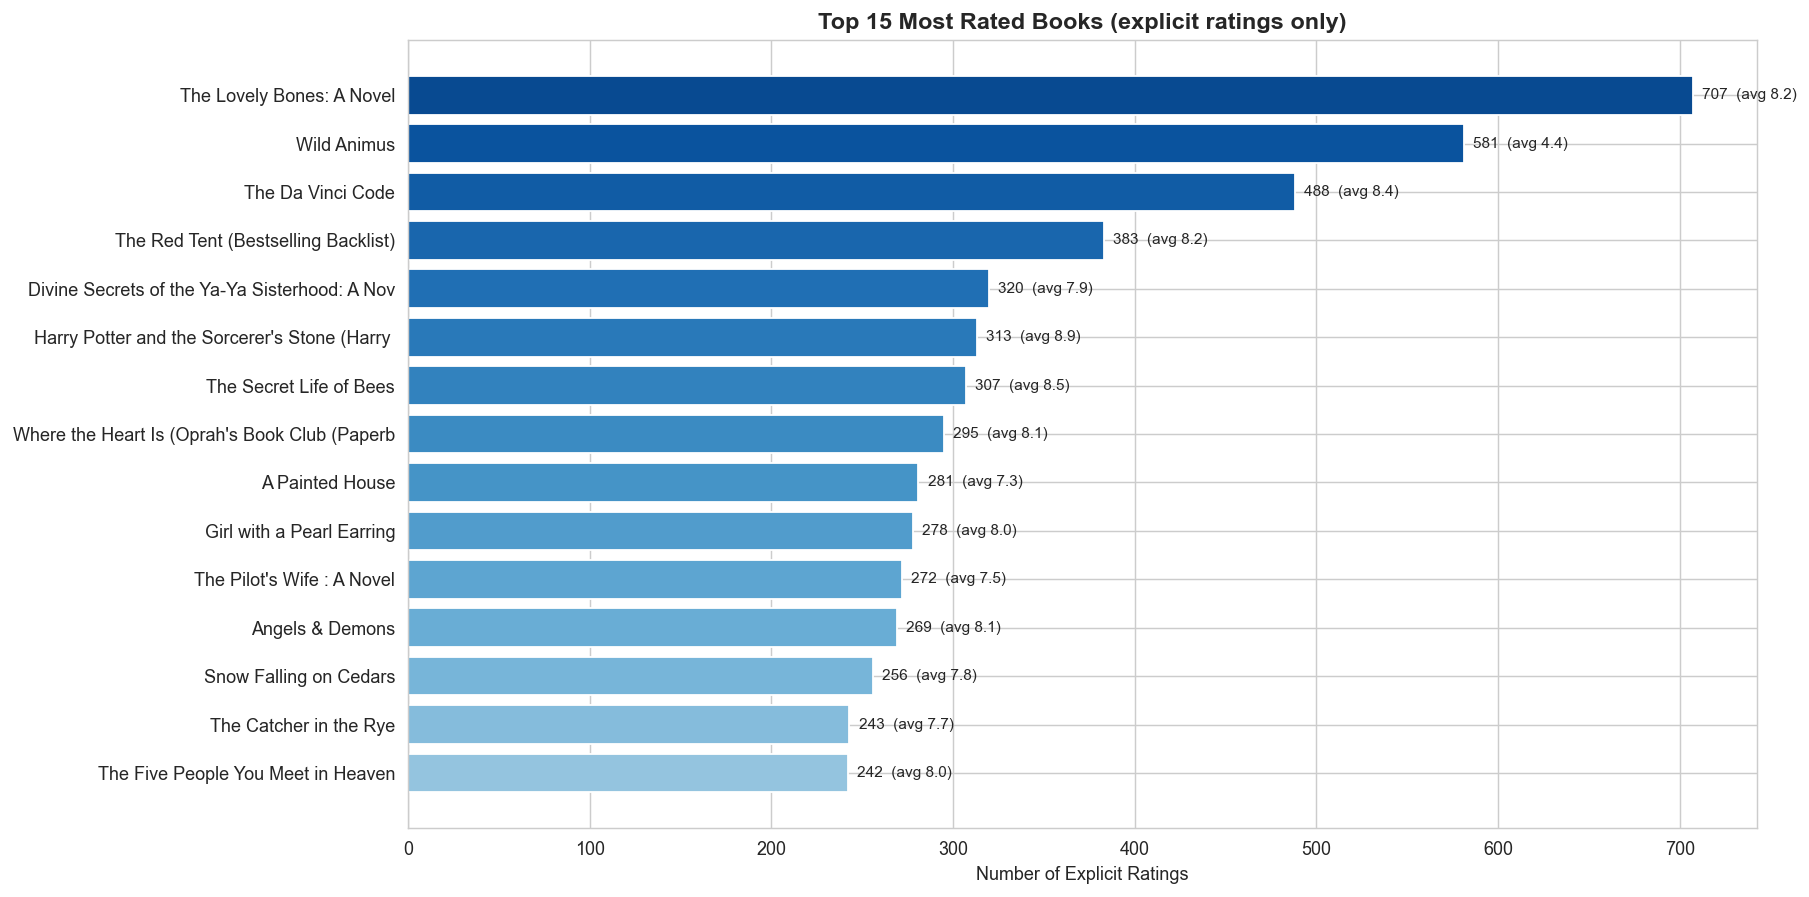

In [9]:
# Join ratings with book titles
top_rated = (
    ratings[ratings['rating'] > 0]
    .groupby('isbn')
    .agg(n_ratings=('rating', 'count'), avg_rating=('rating', 'mean'))
    .reset_index()
    .merge(books[['isbn', 'title', 'author']], on='isbn', how='left')
    .dropna(subset=['title'])
    .sort_values('n_ratings', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    top_rated['title'].str[:45][::-1],
    top_rated['n_ratings'][::-1],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, 15))
)
ax.set_title('Top 15 Most Rated Books (explicit ratings only)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Explicit Ratings')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, (_, row) in zip(bars[::-1], top_rated.iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{row['n_ratings']:,}  (avg {row['avg_rating']:.1f})",
            va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('../assets/top_rated_books.png', bbox_inches='tight')
plt.show()

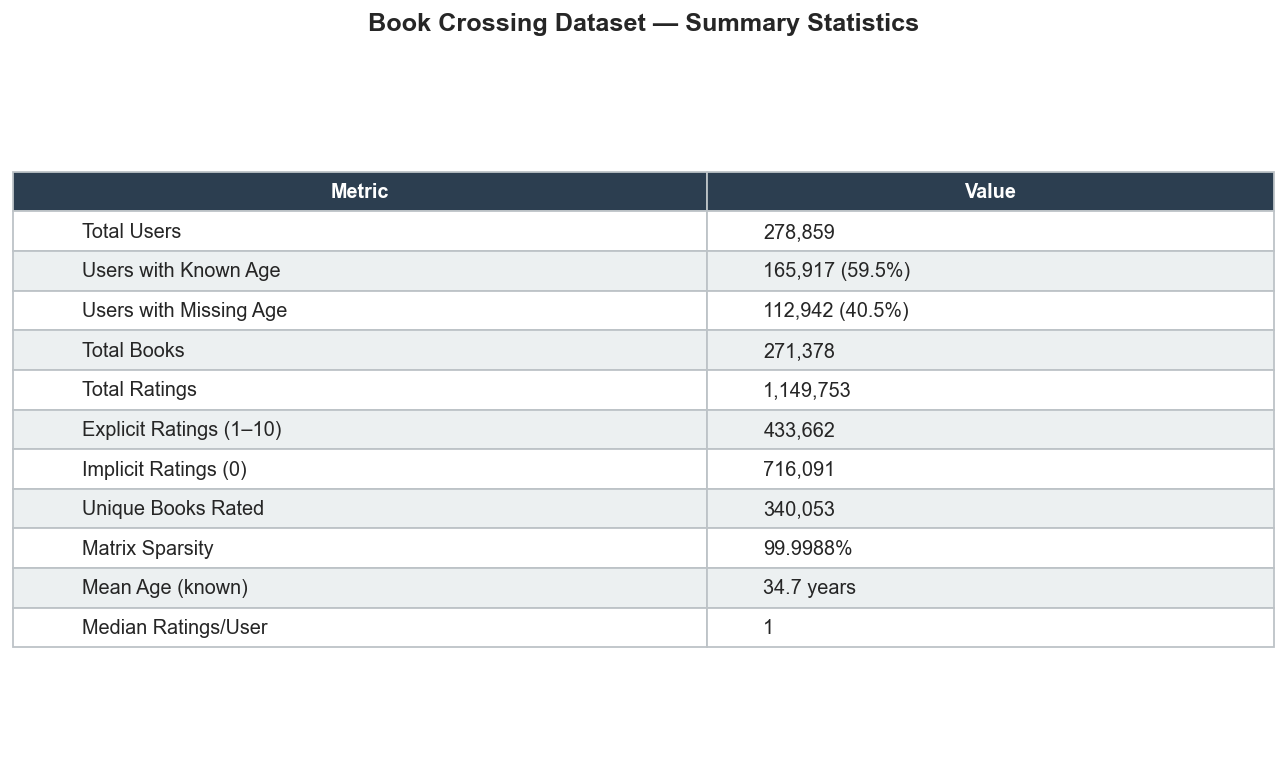

In [10]:
summary_data = {
    'Metric': [
        'Total Users', 'Users with Known Age', 'Users with Missing Age',
        'Total Books', 'Total Ratings', 'Explicit Ratings (1–10)',
        'Implicit Ratings (0)', 'Unique Books Rated',
        'Matrix Sparsity', 'Mean Age (known)', 'Median Ratings/User'
    ],
    'Value': [
        f"{clean.n_users:,}",
        f"{clean.n_users_with_age:,} ({clean.n_users_with_age/clean.n_users*100:.1f}%)",
        f"{clean.n_users_without_age:,} ({clean.n_users_without_age/clean.n_users*100:.1f}%)",
        f"{clean.n_books:,}",
        f"{clean.n_ratings:,}",
        f"{(ratings['rating'] > 0).sum():,}",
        f"{(ratings['rating'] == 0).sum():,}",
        f"{clean.n_unique_rated_books:,}",
        f"{clean.sparsity:.4%}",
        f"{users[users['age'].notna()]['age'].mean():.1f} years",
        f"{ratings.groupby('user_id').size().median():.0f}"
    ]
}

df_summary = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc='left',
    loc='center',
    colWidths=[0.55, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#bdc3c7')

ax.set_title('Book Crossing Dataset — Summary Statistics',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../assets/dataset_summary.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
print("=" * 50)
print("  EDA Complete — all charts saved to assets/")
print("=" * 50)
print()
print("Charts saved:")
import os
for f in sorted(os.listdir('../assets')):
    size = os.path.getsize(f'../assets/{f}')
    print(f"  {f:<35} {size/1024:.1f} KB")

  EDA Complete — all charts saved to assets/

Charts saved:
  age_distribution.png                64.8 KB
  dataset_summary.png                 82.0 KB
  rating_distribution.png             53.7 KB
  sparsity_heatmap.png                41.6 KB
  top_authors_publishers.png          105.9 KB
  top_rated_books.png                 98.0 KB
